## 2.0. Intro

In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import yeojohnson

RANDOM_STATE = 10
DATA_PATH = "data/raw/"

In [2]:
# Extract CSV's to PD's dataframes
df_financial = pd.read_csv(DATA_PATH + "financial_impact.csv")
df_incidents = pd.read_csv(DATA_PATH + "incidents_master.csv")
df_market    = pd.read_csv(DATA_PATH + "market_impact.csv")

# Merge the extracted dataframes into a master 
df_merged = df_incidents.merge(df_financial, on='incident_id', how='inner').merge(df_market, on='incident_id', how='inner') # TODO explain why inner merged?

In [3]:
# Distinguish between numerical and categorical features
def update_feature_types(df):
    numerical_features = df.select_dtypes(include=['number']).columns
    categorical_features = df.select_dtypes(include=['object', 'string', 'category', 'bool']).columns
    return numerical_features, categorical_features

In [4]:
num_cols, cat_cols = update_feature_types(df_merged)

# Filter the categorical features by whether they are relevant to our project and will be used later in our systems
cat_cols_relevant = ["country_hq", "attack_vector_primary"] # TODO update with chosen categoricals needed by our 3 systems

## 2.1. Data Deletion: Missing Values

Explanation

In [5]:
def compute_missing_stats(df):
    missing_cols = pd.DataFrame({'missing_count': df.isna().sum()})
    missing_cols['missing_%'] = (missing_cols['missing_count'] / df.shape[0] * 100).round(2)
    missing_cols = missing_cols.sort_values('missing_%', ascending=False)

    missing_rows = pd.DataFrame({'missing_count': df.isna().sum(axis=1)})
    missing_rows['missing_%'] = (missing_rows['missing_count'] / df.shape[1] * 100).round(2)
    missing_rows = missing_rows.sort_values('missing_%', ascending=False)

    return missing_cols, missing_rows

def get_cols_rows_to_drop(missing_cols, missing_rows, threshold_cols=30, threshold_rows=60):
    cols_to_drop = missing_cols[missing_cols["missing_%"] > threshold_cols]
    rows_to_drop = missing_rows[missing_rows["missing_%"] > threshold_rows]

    return cols_to_drop, rows_to_drop

In [6]:
miss_threshold_cols = 30  # drop columns with more than 30% missing
miss_threshold_rows = 60  # drop rows with more than 60% missing

missing_cols, missing_rows = compute_missing_stats(df_merged)
cols_to_drop, rows_to_drop = get_cols_rows_to_drop(missing_cols, missing_rows)

cell_count         = df_merged.size
missing_cell_count = missing_cols["missing_count"].sum()
missing_cell_pct   = round(missing_cell_count / cell_count * 100, 2)
col_count          = df_merged.shape[1]
missing_col_count  = (missing_cols["missing_count"] > 0).sum()
missing_col_pct    = round(missing_col_count / col_count * 100, 2)

# Summary
print("=" * 100)
print("MISSING VALUES")
print("=" * 100)

print()
print(f"{missing_cell_count} of {cell_count} cells ({missing_cell_pct}%) containing missing values")
print(f"{missing_col_count} of {col_count} features ({missing_col_pct}%) containing missing values")

print()
print(f"{len(cols_to_drop)} features ({len(cols_to_drop)/len(missing_cols)*100:.1f}%) exceeding the {miss_threshold_cols}% missing threshold for columns")
print(f"{len(rows_to_drop)} observations ({len(rows_to_drop)/len(missing_rows)*100:.1f}%) exceeding the {miss_threshold_rows}% missing threshold for rows")

print()
print(f"Top features by missing proportion:")
display(missing_cols.head(20))
print()

# Drop rows and columns exceeding the set thresholds
df_miss = df_merged.drop(index=rows_to_drop.index).drop(columns=cols_to_drop.index).copy()
num_cols, cat_cols = update_feature_types(df_miss) # Update

# Drop rows if have no value for target features (useless for classification)
print(f"Missing values in relevant categorical features:")
for col in cat_cols_relevant:
    print(f"    {int(df_miss[col].isna().sum())} rows with missing values corresponding to feature {col}")
print()

# Drop duplicate rows (if any)
print(f"{df_miss.duplicated().sum()} duplicated observations in the dataset to be dropped")

print()
print("=" * 100)

MISSING VALUES

3780 of 26320 cells (14.36%) containing missing values
19 of 80 features (23.75%) containing missing values

16 features (20.0%) exceeding the 30% missing threshold for columns
0 observations (0.0%) exceeding the 60% missing threshold for rows

Top features by missing proportion:


,missing_count,missing_%
review_flag,297,90.27
ransom_paid_usd,289,87.84
ransom_source,289,87.84
industry_secondary,278,84.50
regulatory_fine_usd,276,83.89
attack_vector_secondary,252,76.60
notes_x,246,74.77
ransom_demanded_usd,245,74.47
notes,245,74.47
notes_y,228,69.30



Missing values in relevant categorical features:
    0 rows with missing values corresponding to feature country_hq
    0 rows with missing values corresponding to feature attack_vector_primary

0 duplicated observations in the dataset to be dropped



## 2.2. Data Deletion: Outliers

Explanation

In [7]:
def get_outlier_bounds(df, cols):
    bounds = df[cols].quantile([0.25, 0.75])
    bounds.index = ["Q1", "Q3"]
    bounds.loc["IQR"]         = bounds.loc["Q3"] -       bounds.loc["Q1"]
    bounds.loc["inner_lower"] = bounds.loc["Q1"] - 1.5 * bounds.loc["IQR"]
    bounds.loc["inner_upper"] = bounds.loc["Q3"] + 1.5 * bounds.loc["IQR"]
    bounds.loc["outer_lower"] = bounds.loc["Q1"] - 3.0 * bounds.loc["IQR"]
    bounds.loc["outer_upper"] = bounds.loc["Q3"] + 3.0 * bounds.loc["IQR"]
    return bounds

In [8]:
def get_outlier_masks(df, cols):
    bounds = get_outlier_bounds(df, cols)
    # Potential outliers (inner fence, includes extreme outliers)
    outlier_mask_inner = (df[cols] < bounds.loc["inner_lower"]) | (df[cols] > bounds.loc["inner_upper"])
    # Extreme outliers (outer fence, subset of the previous)
    outlier_mask_outer = (df[cols] < bounds.loc["outer_lower"]) | (df[cols] > bounds.loc["outer_upper"])
    return outlier_mask_inner, outlier_mask_outer

In [9]:
def get_outlier_stats(df, cols):
    outlier_mask_inner, outlier_mask_outer = get_outlier_masks(df, cols)
    outlier_stats = pd.DataFrame({
    "inner_count":   (outlier_mask_inner & ~outlier_mask_outer).sum(),
    "inner_%":     (outlier_mask_inner & ~outlier_mask_outer).mean() * 100,
    "outer_count": outlier_mask_outer.sum(),
    "outer_%":   outlier_mask_outer.mean() * 100,
    "total_count":   outlier_mask_inner.sum(),
    "total_%":     outlier_mask_inner.mean() * 100,}).round(2)
    return outlier_stats

In [ ]:
def plot_outlier_boxplots(df, cols, title="Boxplot: Outlier Detection", max_cols_per_row=15):
    inner_mask, outer_mask = get_outlier_masks(df, cols)

    boxplot_style = {
        'patch_artist'  : True,
        'flierprops'    : {'marker': ''},
        'capprops'      : {'color': 'silver', 'linewidth': 1.5},
        'whiskerprops'  : {'color': 'silver', 'linewidth': 0.5},
        'medianprops'   : {'color': 'gray',   'linewidth': 2},
        'boxprops'      : {'facecolor': 'lightgray', 'linewidth': 0}}

    # Split cols into chunks of max_cols_per_row
    chunks = [cols[i:i + max_cols_per_row] for i in range(0, len(cols), max_cols_per_row)]

    for chunk in chunks:
        fig, axes = plt.subplots(1, len(chunk), figsize=(len(chunk)*2, 6))
        if len(chunk) == 1:
            axes = [axes]

        jitter = 0.05
        for ax, col in zip(axes, chunk):
            data        = df[col].dropna()
            idx         = data.index
            inner_fence = data[(inner_mask & ~outer_mask)[col].reindex(idx, fill_value=False)]
            outer_fence = data[outer_mask[col].reindex(idx, fill_value=False)]

            ax.boxplot(data, tick_labels=[col], **boxplot_style)
            ax.scatter(1 + np.random.uniform(-jitter, jitter, len(inner_fence)), inner_fence,
                    color='orange', label='Mild (1.5×IQR)',   alpha=0.5, s=20, zorder=3)
            ax.scatter(1 + np.random.uniform(-jitter, jitter, len(outer_fence)), outer_fence,
                    color='red',    label='Extreme (3×IQR)', alpha=0.5, s=20, zorder=3)
            ax.set_title(col, fontsize=8)
            ax.set_xticks([]) 
            ax.set_yticks([])
            sns.despine(ax=ax, bottom=True, left=True) 

        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper right')
        plt.suptitle(title, y=1.02)
        plt.tight_layout()
        plt.show()

OUTLIERS (1/2)

Top features by outlier proportion:


,inner_count,inner_%,outer_count,outer_%,total_count,total_%
p_value_30d,0,0.00,82,24.92,82,24.92
volume_disclosure_day,16,4.86,29,8.81,45,13.68
legal_fees_usd,18,5.47,23,6.99,41,12.46
direct_loss_usd,17,5.17,23,6.99,40,12.16
market_cap_at_disclosure,26,7.90,13,3.95,39,11.85
price_1d_after,26,7.90,13,3.95,39,11.85
price_disclosure_day,24,7.29,14,4.26,38,11.55
price_7d_after,26,7.90,12,3.65,38,11.55
recovery_cost_usd,15,4.56,23,6.99,38,11.55
inflation_adjusted_usd,16,4.86,22,6.69,38,11.55


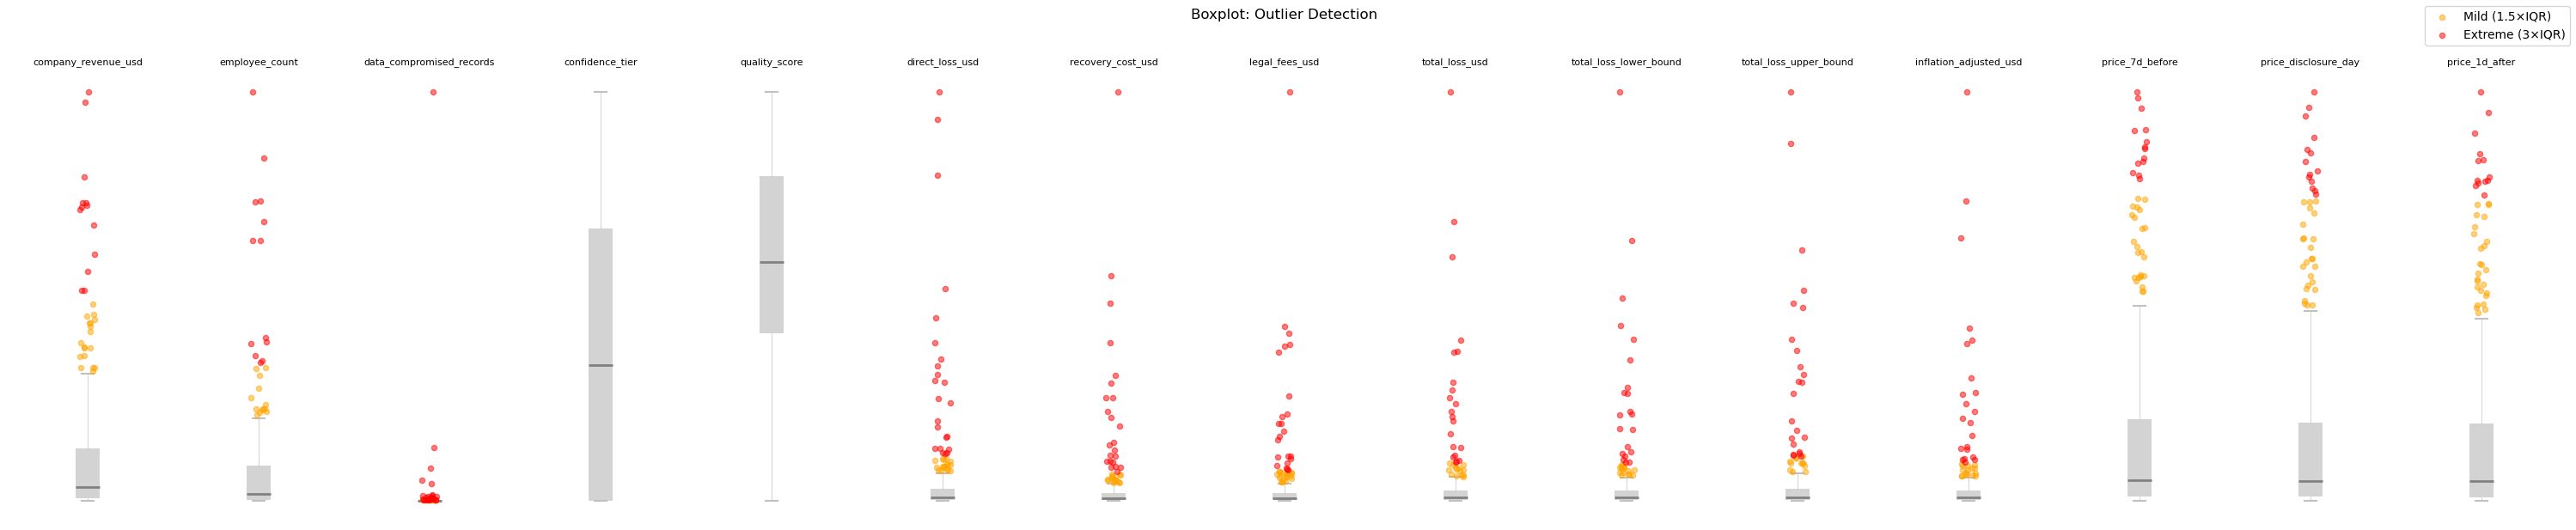

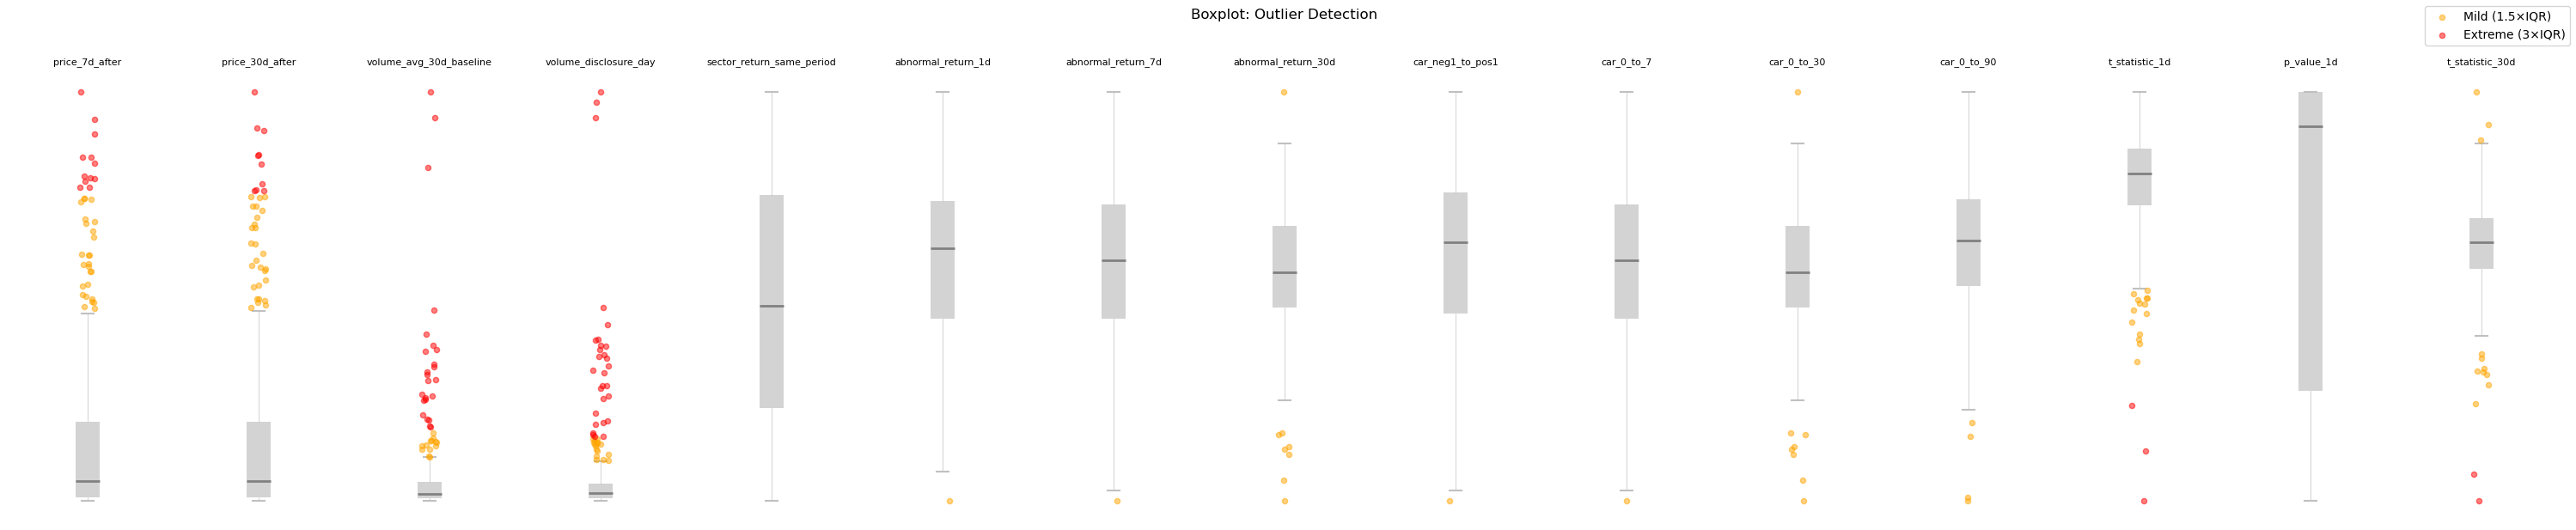

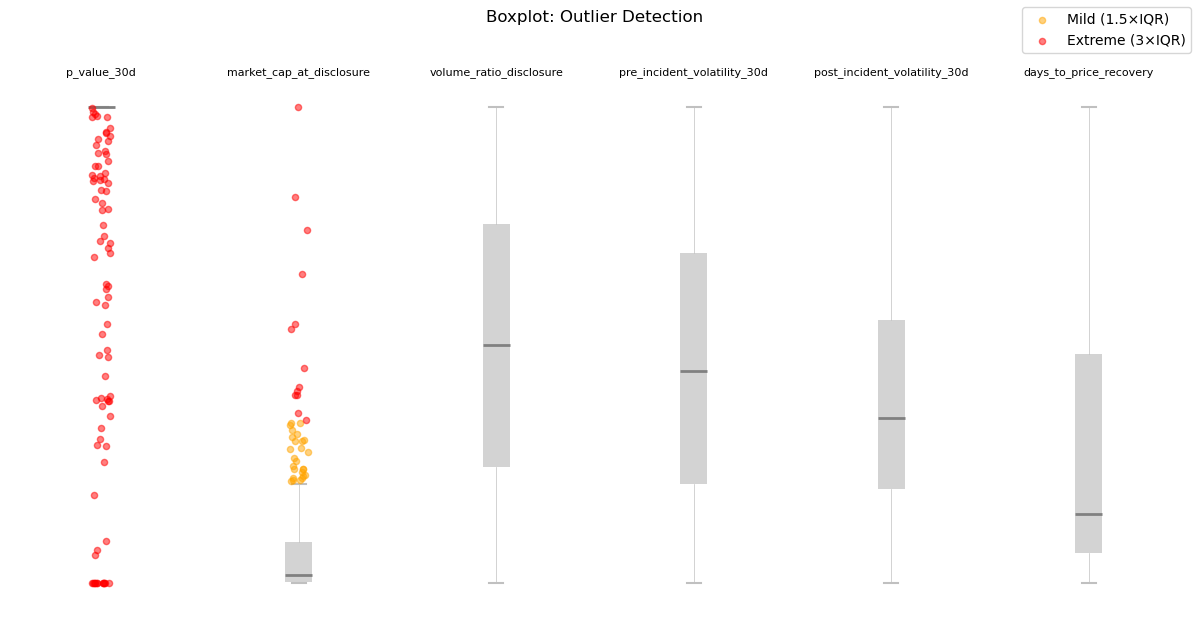

In [92]:
print("=" * 100)
print("OUTLIERS (1/2)")
print("=" * 100)

print()
print("Top features by outlier proportion:")
outlier_stats = get_outlier_stats(df_miss, num_cols)
display(outlier_stats.sort_values(by="total_%", ascending=False).iloc[:20].head(15))
print()

plot_outlier_boxplots(df_miss, num_cols)
print()
print("=" * 100)

The boxplots show a fair amount of outliers, in both the inner and the outer fence.

We can observe those graphs reflect the range of variance in nature of the companies subject to our study: they are very diverse in terms of different aspects such as economy and workforce dimensions.

We deem those values to be valuable and valid data, therefore mantaining the features for now, but will transform the highly skewed features.

We will be using the Yeo-Johnson method, as in contrast to logarithmic and other transformations, it can be performed on negatively/left-skewed in addition to positively/right-skewed features.

In [12]:
def yeojohnson_transform_skewness(df, cols, skew_threshold=1, skip_cols=[]):
    df_out    = df.copy()
    skewness  = df[cols].skew()

    for col, skew in zip(cols, skewness):
        if col not in skip_cols:
            if abs(skew) > skew_threshold:
                mask = df_out[col].notna() # Yeo-Johnson returns error when it finds NaN values
                df_out[col] = df_out[col].astype(float) # Yeo-Johnson expects float values and returns error if it finds integer features
                df_out.loc[mask, col], _ = yeojohnson(df_out.loc[mask, col])
                
    return df_out

In [13]:
def display_skewness_comparison(df_before, df_after, cols, skew_threshold=1):
    skew_before = df_before[cols].skew()
    skew_after  = df_after[cols].skew()

    comparison = pd.DataFrame({
        "before"  : skew_before,
        "after"   : skew_after}).round(4)

    comparison["inside_threshold"] = comparison["after"].abs() < skew_threshold

    comparison = comparison.sort_values("before", ascending=False)
    display(comparison)
    
     # Originally left / right skewed
    left = comparison["before"] < -skew_threshold
    right = comparison["before"] > skew_threshold

    left_corrected = (left & comparison["inside_threshold"]).sum()
    right_corrected = (right & comparison["inside_threshold"]).sum()

    total_left = left.sum()
    total_right = right.sum()

    still_skewed = comparison.index[~comparison["inside_threshold"]].tolist()

    print(f"{left_corrected} of {total_left} left-skewed features corrected")
    print(f"{right_corrected} of {total_right} right-skewed features corrected")
    print()
    
    print(f"{len(still_skewed)} of {len(cols)} features still over absolute skewness threshold of {skew_threshold}:")
    for col in still_skewed:
        print(f"    \"{col}\"")

SKEWNESS

Skewness before and after Yeo-Johnson:


,before,after,inside_threshold
data_compromised_records,14.6042,0.0189,True
recovery_cost_usd,7.6848,-0.0002,True
legal_fees_usd,7.6132,0.0019,True
total_loss_lower_bound,6.7775,0.0004,True
total_loss_usd,6.7474,-0.0002,True
inflation_adjusted_usd,6.6254,-0.0002,True
direct_loss_usd,6.1231,-0.0002,True
total_loss_upper_bound,5.7888,0.0001,True
volume_avg_30d_baseline,5.1792,0.0033,True
volume_disclosure_day,4.8869,0.0036,True


2 of 3 left-skewed features corrected
18 of 18 right-skewed features corrected

1 of 36 features still over absolute skewness threshold of 1:
    "p_value_30d"



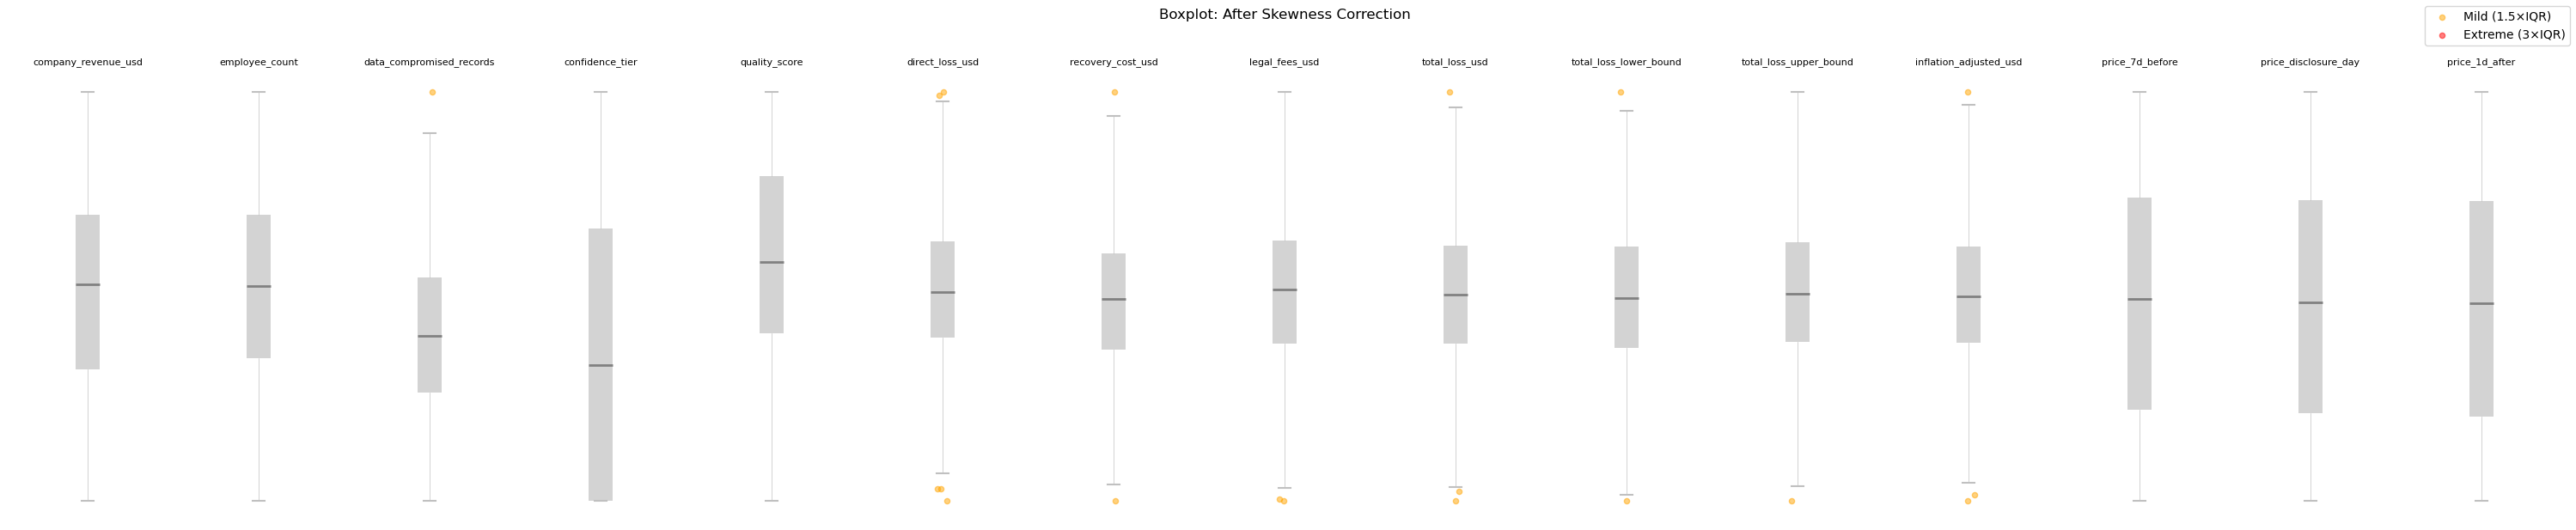

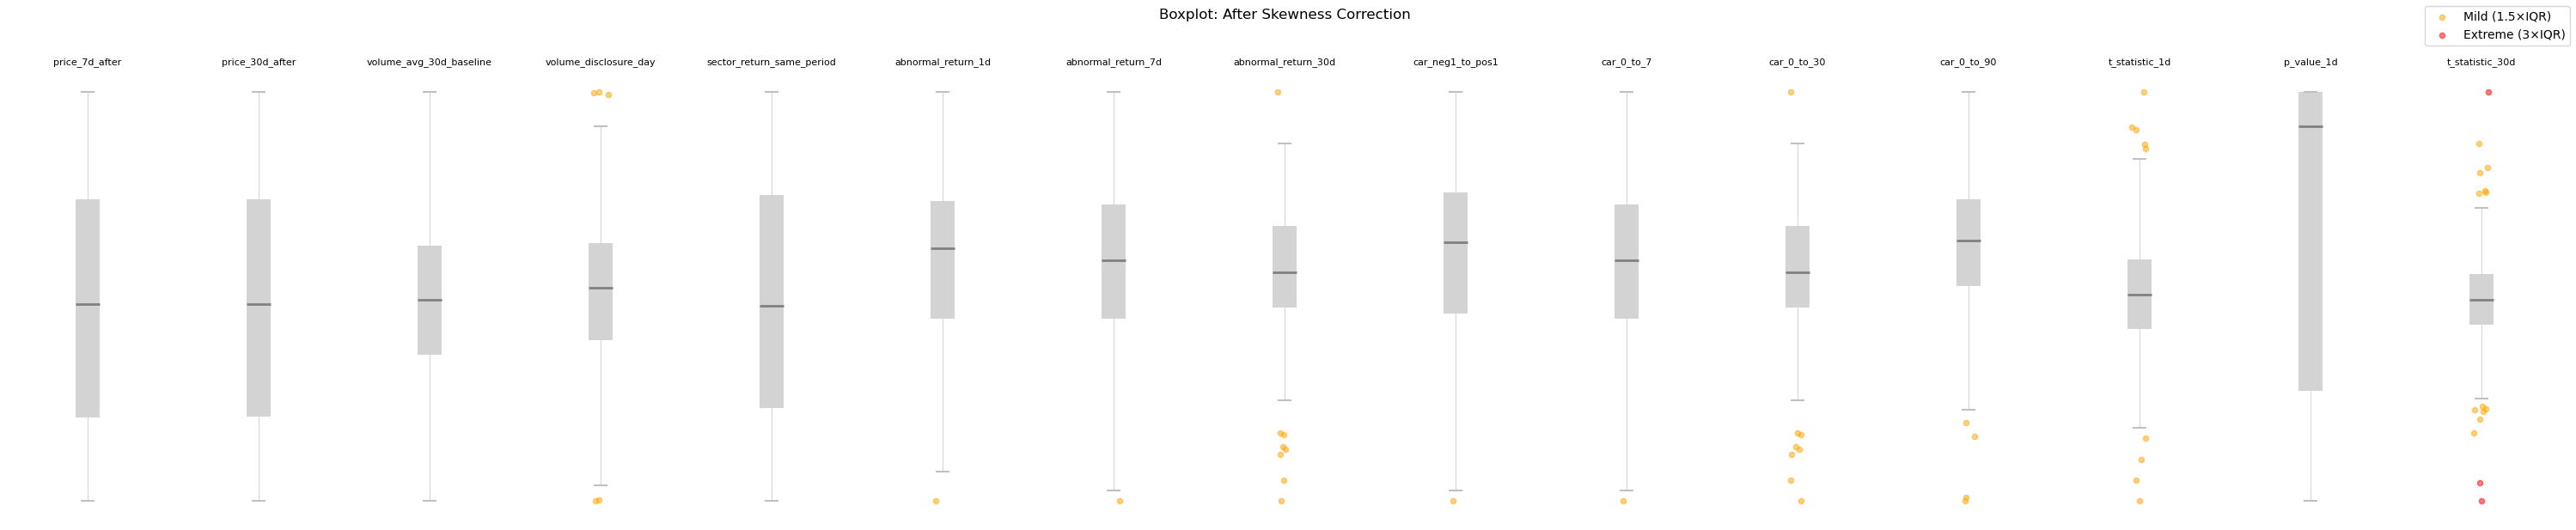

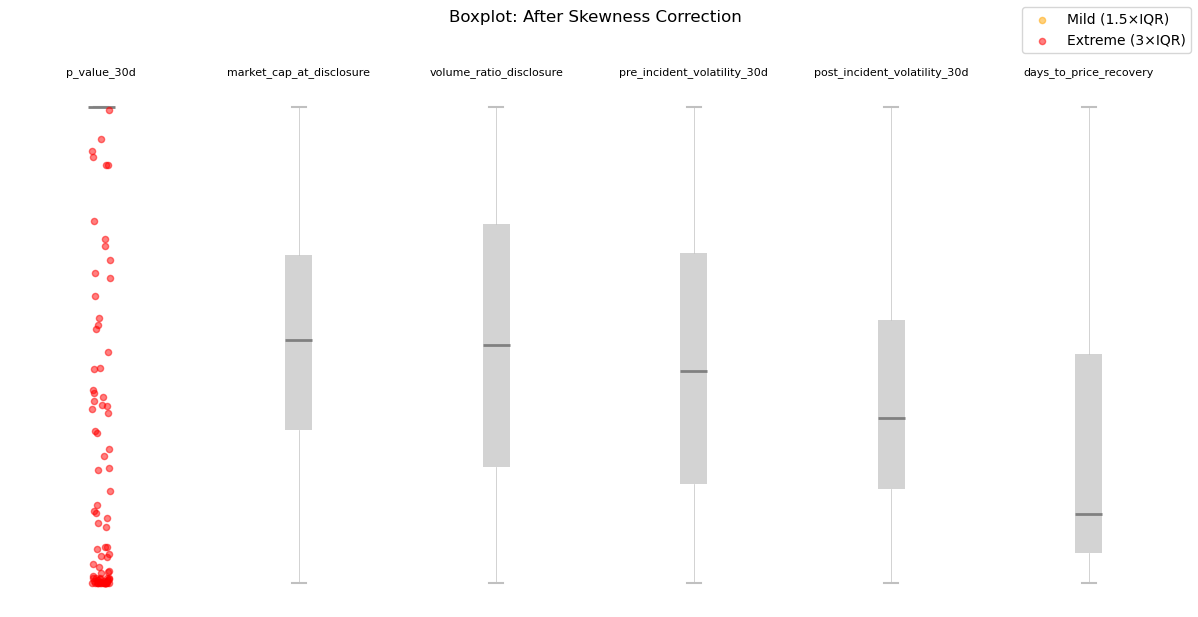

In [93]:
print("=" * 100)
print("SKEWNESS")
print("=" * 100)

print()
print("Skewness before and after Yeo-Johnson:")
# Apply skewness correction:
df_skew = yeojohnson_transform_skewness(df_miss, num_cols).copy()
display_skewness_comparison(df_miss, df_skew, num_cols)
print()

plot_outlier_boxplots(df_skew, num_cols, title="Boxplot: After Skewness Correction")    
print()
print("=" * 100)

Yeo-Johnson transformation was performed on the dataset to correct the skewness individually.

Skewness has been improved remarkably, although distribution is in counted cases not centered.

At this point some rows with extreme outliers still remain, which will be dropped.

In [31]:
def drop_outliers(df, cols, fence="outer", skip_cols=[]):
    cols_to_check = [col for col in cols if col not in skip_cols]
    mask_inner, mask_outer = get_outlier_masks(df, cols)

    if fence == "inner":           
        mask = mask_inner
    else:
        mask = mask_outer

    df_out = df[~rows_to_drop]
    return df_out, rows_to_drop

In [37]:
print("=" * 100)
print("OUTLIERS (2/2)")
print("=" * 100)

print()
print("Top features by outlier proportion:")
outlier_stats = get_outlier_stats(df_skew, num_cols)
display(outlier_stats.sort_values(by="total_%", ascending=False).iloc[:20].head(15))
print()

df_out, rows_to_drop = drop_outliers(df_skew, num_cols, fence="both", skip_cols="p_value_30d")

print(f"{rows_to_drop.sum()} of {len(df_skew)} rows ({rows_to_drop.mean()*100:.1f}%) dropped")
print(f"{len(df_out)} rows remaining")

print()
print("=" * 100)

OUTLIERS (2/2)

Top features by outlier proportion:


,inner_count,inner_%,outer_count,outer_%,total_count,total_%
p_value_30d,0,0.00,82,24.92,82,24.92
t_statistic_30d,12,3.65,3,0.91,15,4.56
t_statistic_1d,9,2.74,0,0.00,9,2.74
abnormal_return_30d,8,2.43,0,0.00,8,2.43
car_0_to_30,8,2.43,0,0.00,8,2.43
direct_loss_usd,5,1.52,0,0.00,5,1.52
volume_disclosure_day,5,1.52,0,0.00,5,1.52
car_0_to_90,4,1.22,0,0.00,4,1.22
inflation_adjusted_usd,3,0.91,0,0.00,3,0.91
total_loss_usd,3,0.91,0,0.00,3,0.91



3 of 329 rows (0.9%) dropped
326 rows remaining



## 2.3. Feature Encoding

Explanation
Which cat columns to keep and how to encode:

In [39]:
def encode_categorical(df, cols):
    df_enc   = df.copy()
    mappings = {}

    for col in cols:
        le                    = LabelEncoder()
        df_enc[f"{col}_encoded"] = le.fit_transform(df_enc[col])
        # Keep the mapping for future interpretability
        mappings[col]         = {label: idx for idx, label in enumerate(le.classes_)}

    return df_enc, mappings

In [ ]:
def plot_donut_chart(df, col, ax=None):
    counts  = df[col].value_counts()
    palette = sns.color_palette("YlOrRd_r", len(counts))

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    wedges, _, autotexts = ax.pie(
        counts,
        autopct     = '%1.1f%%',
        colors      = palette,
        startangle  = -180,
        pctdistance = 0.65,
        wedgeprops  = {'linewidth': 1, 'edgecolor': 'white', 'width': 0.5})

    for t in autotexts:
        t.set_fontsize(8)

    ax.legend(wedges, counts.index, loc="upper left", fontsize=8, frameon=False)
    ax.set_title(f"Donut chart: \"{col}\"", fontsize=11, pad=15)
    ax.set_ylabel("")

ENCODED FEATURES

Feature: country_hq

Labels summary:


country_hq,US,GB,DE,CA,FR,AU,JP,IN,CH,BR,...,BE,AE,PT,HK,SE,MY,TW,CL,PL,AR
count,119.0,34.00,21.00,18.00,16.00,14.00,12.00,9.00,8.00,6.00,...,3.00,2.00,2.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
%,36.5,10.43,6.44,5.52,4.91,4.29,3.68,2.76,2.45,1.84,...,0.92,0.61,0.61,0.31,0.31,0.31,0.31,0.31,0.31,0.31


Mapping:


label,AE,AR,AT,AU,BE,BR,CA,CH,CL,DE,...,NL,NO,PH,PL,PT,SE,SG,TW,US,ZA
encoded,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31


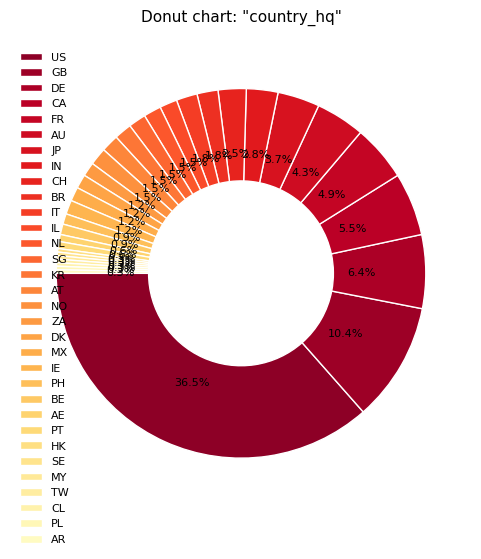


Feature: attack_vector_primary

Labels summary:


attack_vector_primary,ransomware,data_breach,phishing,apt,ddos,malware,supply_chain,backdoor,trojan
count,83.00,56.00,54.00,39.00,27.00,19.00,19.00,15.0,14.00
%,25.46,17.18,16.56,11.96,8.28,5.83,5.83,4.6,4.29


Mapping:


label,apt,backdoor,data_breach,ddos,malware,phishing,ransomware,supply_chain,trojan
encoded,0,1,2,3,4,5,6,7,8


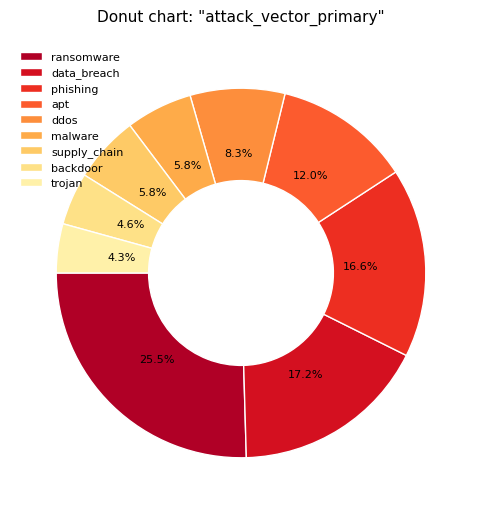

In [ ]:
print("=" * 100)
print("ENCODED FEATURES")
print("=" * 100)

# Reduced categorical features dataframe
df_enc = df_out[list(num_cols) + cat_cols_relevant].copy()

df_enc, mappings = encode_categorical(df_enc, cat_cols_relevant)

for col in cat_cols_relevant:
    print()
    print(f"Feature: \"{col}\"")
    target = df_enc[col]
    target_summary = pd.DataFrame({"count": target.value_counts(), "%": target.value_counts(normalize=True) * 100}).round(2)
    print()

    print("Labels summary:")
    display(target_summary.T)
    print("Mapping:")
    display(pd.DataFrame(mappings[col].items(), columns=["label", "encoded"]).set_index("label").T)

    fig, ax = plt.subplots(figsize=(6, 6))
    plot_donut_chart(df_out, col, ax=ax)  # pass ax
    display(fig)
    plt.close(fig)
    
print()
print("=" * 100)

We choose attack_vector_primary as our goal target for classification because...

There's a clear class imbalance...

## 2.4. Training Dataset Preparation

Explanation
Data split (avoid leakage, explain)
validation set?? size

In [ ]:
df_num = df_enc[num_cols] # TODO reduce to a function

y = df_enc["attack_vector_primary"]
X = df_num

In [ ]:
# 2-step split of the dataset in 3 subsets: 60% train, 20% val, 20% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE)

# Full version of the dataset for future use
X_full = df_num

In [ ]:
print("=" * 100) # TODO Need to address class imbalance and lack of enough class observations
print("DATASET SPLIT SUMMARY")
print("=" * 100)

print(f"\nTotal observations : {len(X)}")
print(f"Total features     : {X.shape[1]}")
print(f"Target             : attack_vector_primary ({y.nunique()} classes)")

print(f"\nSplit:")
print(f"  Train:      {len(X_train):>4} observations ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Validation: {len(X_val):>4} observations ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test:       {len(X_test):>4} observations ({len(X_test)/len(X)*100:.1f}%)")

print(f"\nClass distribution:") # TODO swap print() for \n in previous parts!!!!

classes = sorted(y.unique())

class_dist = pd.DataFrame({
    "train": [(y_train == c).sum() for c in classes],
    "val":   [(y_val == c).sum() for c in classes],
    "test":  [(y_test == c).sum() for c in classes]}, index=classes)

display(class_dist)

print()
print("=" * 100) # TODO organize better tabs and spaces like in here, looks spacious and light

DATASET SPLIT SUMMARY

Total observations : 326
Total features     : 36
Target             : attack_vector_primary (9 classes)

Split:
  Train:       195 observations (59.8%)
  Validation:   65 observations (19.9%)
  Test:         66 observations (20.2%)

Class distribution:


,train,val,test
apt,23,8,8
backdoor,9,3,3
data_breach,34,11,11
ddos,16,5,6
malware,11,4,4
phishing,32,11,11
ransomware,50,16,17
supply_chain,11,4,4
trojan,9,3,2


Classes are imbalanced (Stratified KFold) and have too few samples each (KNN needs at least 15-20 of each - solution: merge classes)

## 2.5. Data Imputation

Explanation

In [146]:
imputer = IterativeImputer(estimator=BayesianRidge(), max_iter=10) # TODO show data on imputation

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)
X_val_imp = imputer.transform(X_val)

X_full_imp = imputer.transform(X_full)

## 2.6. Data Scaling

StandardScaler and centering for PCA:
StandardScaler centers to mean=0 and std=1 exactly by definition — that's precisely what PCA needs. AND WHAT OTHER COMPUTATIONS ALSO REQUIRE SCALED DATA? AND WHY?
You don't need any additional centering step. The mean won't be exactly 0 in floating point arithmetic, 
but it will be on the order of 1e-16, which is negligible.


Why scale? To prevent features from dominating or having more weight because of the value range. Justify why it is something bad

In [147]:
# Fit scaler on train only to avoid data leaking
scaler = StandardScaler()

X_train_scl = scaler.fit_transform(X_train_imp)
X_val_scl   = scaler.transform(X_val_imp)
X_test_scl  = scaler.transform(X_test_imp)

X_full_scl = scaler.transform(X_full_imp)

In [20]:
def scaling_summary(name, data):
    df = pd.DataFrame(data, columns=num_cols)
    summary = pd.DataFrame({"mean": df.mean(), "std": df.std(), "min": df.min(), "max":  df.max()}).round(4)
    print(f"\n{name}:")
    print(summary)

scaling_summary("X_train_scaled", X_train_scaled)
scaling_summary("X_val_scaled",   X_val_scaled)
scaling_summary("X_test_scaled",  X_test_scaled)
scaling_summary("X_full_scaled",  X_full_scaled)


X_train_scaled:
                              mean     std     min      max
company_revenue_usd            0.0  1.0038 -0.7127   3.7252
employee_count                 0.0  1.0038 -0.5802   5.7998
data_compromised_records       0.0  1.0038 -0.1460  11.3665
confidence_tier                0.0  1.0038 -0.8602   1.6255
quality_score                  0.0  1.0038 -2.1091   1.5982
direct_loss_usd                0.0  1.0038 -0.4750   6.2781
recovery_cost_usd              0.0  1.0038 -0.4883   5.6980
legal_fees_usd                 0.0  1.0038 -0.4331   6.2537
total_loss_usd                -0.0  1.0038 -0.4839   5.6473
total_loss_lower_bound        -0.0  1.0038 -0.4846   6.0631
total_loss_upper_bound         0.0  1.0038 -0.4595   6.1145
inflation_adjusted_usd        -0.0  1.0038 -0.4707   6.1670
price_7d_before               -0.0  1.0038 -0.7479   2.7987
price_disclosure_day          -0.0  1.0038 -0.7480   3.0302
price_1d_after                 0.0  1.0038 -0.7496   2.9679
price_7d_after         

X_train — mean=0.0, std≈1.0038 for every feature, exactly as expected since the scaler was fitted here.
X_val, X_test, X_full — mean slightly off 0 and std slightly off 1, which is expected and correct. They were only transformed using train statistics, not fitted. This is the proof that there is no leakage.

## 2.7. Feature selection (NOT NEEDED, OR COULD PERFORM BEFORE TO AVOID USELESS WORK ON THEM?)

Explain

Feature selection before PCA?
Not strictly necessary, but useful if you have:

Redundant features — highly correlated columns (PCA handles this anyway)
Irrelevant features — noise that could dilute principal components
Many features — PCA computation scales with dimensionality

Remember: "Garbage input results in garbage output"

Feature selection
Numerical versus numerical data:
    •Pearson’s correlation coefficient (linear).
    •Spearman’s rank coefficient (nonlinear)
    •Mutual information (entropy-based)

In [21]:
# TODO decide if and which features to drop

## 2.7. PCA

5. PCA Scope

Apply only to numerical features after scaling
Decide variance threshold to retain (typically 95%)
Keep original features alongside PCA output for the recommender (PCA distances aren't interpretable for recommendations)

Curse of dimensionality: interpret our dimensions in relation to that concept

 PCA finds the directions in feature space along which the data varies the most, and projects everything onto those directions. The eigenvectors are those directions; the eigenvalues tell you how much variance each one captures.
Worth noting that the output components are uncorrelated by construction — relevant because KNN and KMeans both behave better without correlated features

Your specific choice (95% variance threshold)

Justify the 95% — it's a common default but state it explicitly: you're accepting a 5% information loss in exchange for dimensionality reduction
After running PCA, add a scree plot (cumulative explained variance vs. number of components) — it makes the 95% cutoff visual and easy to defend

One important caveat for your project

Since you're also building a recommender, mention that PCA-transformed features are not used for the recommender — distances in PCA space aren't interpretable as "similarity between incidents." The recommender uses the original scaled features directly. You already have this note buried in a planning cell; it belongs here.

3. Computer the covariance matrix
4. Find the eigenvectors and the eigenvalues of the covariance matrix5. Pick the eigenvectors with the highest eigenvalues
6. Project data points to the selected eigenvectors
7. Obtain uncorrelated low-dimensional data, ௞

In [22]:
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)
X_test_pca  = pca.transform(X_test_scaled)
X_full_pca  = pca.transform(X_full_scaled)

In [23]:
print(f"Components selected: {pca.n_components_}")
print(f"Variance retained: {pca.explained_variance_ratio_.sum():.3f}")

Components selected: 14
Variance retained: 0.954


In [24]:
print("Original size of our dataset: ",X_train_scaled.shape)
print("Reduced size of our dataset: ", X_train_pca.shape)

Original size of our dataset:  (131, 36)
Reduced size of our dataset:  (131, 14)


In [31]:
# TODO evaluate how much of the date variance is explained
# Load pca from preprocessing notebook
print(pca.explained_variance_ratio_[:3].sum())  # variance covered by first 3 components

0.5716853785832088


# 2.8. Export Transformed Dataset

PIPELINES

df_reduced_out
    │
    ├── split → scale → PCA → X_train_pca, X_val_pca, X_test_pca, X_full_pca
    │                                       (KMeans + KNN classification)
    │
    └── split → scale → df_full_scaled (columns intact)
                                        (KNN regression + Recommender)

KMeans — clusters incidents into risk profiles, needs PCA arrays (lower-dimensional, no column names needed)

In [25]:
np.save("data/processed/X_full_pca.npy",  X_full_pca) # label all incidents
# Additionally (grouped on KNN section) X_train_pca.npy also to fit KMeans beforehand 

KNN — classifies a new company into a risk profile, needs PCA arrays + labels produced by KMeans

In [26]:
X_train_pca, y_train  # fit
X_val_pca,   y_val    # tune
X_test_pca,  y_test   # evaluate

(array([[-2.65667588,  1.18971662,  0.86645073, ..., -0.79357117,
         -0.99700846,  0.18986385],
        [-0.46593763, -0.87861403, -2.62371898, ..., -1.00116358,
          0.92323415,  1.50934819],
        [-2.74743476,  0.92726271,  0.84788021, ..., -0.28506927,
         -0.57964281,  0.25272889],
        ...,
        [-1.49086357,  1.11143745,  1.06888485, ...,  1.30254879,
          0.19404032, -0.57892508],
        [-0.69298826,  1.39604208,  1.61341681, ...,  0.49936005,
         -0.0581101 , -0.83707772],
        [-3.11297589,  2.57401972,  2.65568793, ..., -1.17550135,
         -0.55854966,  0.1544867 ]]),
 141       phishing
 158            apt
 81        phishing
 126       phishing
 129         trojan
           ...     
 136    data_breach
 122     ransomware
 98      ransomware
 67            ddos
 317           ddos
 Name: attack_vector_primary, Length: 99, dtype: object)

In [27]:
# Classification

np.save("data/processed/X_train_pca.npy", X_train_pca)
np.save("data/processed/X_val_pca.npy",   X_val_pca)
np.save("data/processed/X_test_pca.npy",  X_test_pca)

np.save("data/processed/y_train.npy", y_train)
np.save("data/processed/y_val.npy",   y_val)
np.save("data/processed/y_test.npy",  y_test)

In [29]:
# Regression

# load the full scaled dataframe with column names
df_full_scaled = pd.read_parquet("data/processed/df_full_scaled.parquet")
'''
# separate targets from features
y_loss     = df_full_scaled["total_loss_usd"]
y_recovery = df_full_scaled["days_to_price_recovery"]
X          = df_full_scaled.drop(columns=["total_loss_usd", "days_to_price_recovery"])
'''

ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.

Recommender — finds similar past incidents, needs interpretable features with column names → original scaled dataframe, not PCA. PCA distances aren't human-readable as "this incident is similar because of industry + attack vector".

In [ ]:
np.save("data/processed/X_full_scaled.npy", X_full_scaled)
pd.DataFrame(X_full_scaled, columns=num_cols).to_parquet("data/processed/df_full_scaled.parquet")  # keeps column names TODO make sure only numerical for X_full_scaled too

In [32]:
# TODO Do we need to use systems into other systems , like KNN in recommenders?

# END

In [ ]:
# TODO need to explain all cells
# TODO add prints after actions (removal, etc)
# TODO define targets, hypothesis, question to answer
# At the end, evaluate prediction performance TODO asess performance of Jiarui's KNN classifier with TP TN tables, statistics and ROC curves
# TODO explain in the analysis why we are choosing a selection of categorical features to study, why we find them interesting and what is the purpose, what we expect to do and obtain from them.
# TODO print needed analysis or justsification code for the section core, extract conclusions in a markdown cell, act accordingly by transforming the inputted dataset: PATTERN FOR EACH SECTION
# TODO introduce: what data structure do we need for each posterior system (split, with labels, without PCA, etc.)

In [ ]:
"""
Attack vectors show strong patterns based on company size, industry, and employee count
Ransomware and phishing dominate (60%+), with APTs targeting large enterprises
Financial services and healthcare sectors experience distinct attack patterns
Tree-based ML models achieve 70-75% accuracy in attack vector prediction
Feature importance reveals revenue, employee count, and industry as top predictors
"""

2. Feature Scope

Drop high-missing columns already identified (16 cols)
Drop leakage columns — e.g. total_loss_lower_bound / upper_bound if predicting total_loss_usd
Drop identifiers — incident_id, company_name, stock_ticker_*
Drop redundant date columns — created_at_*, updated_at_*
Decide on p_value_30d — zero IQR problem we identified

4. Recommender System Design
This is the most open-ended decision. What is the entity being recommended?

"Given this incident profile, find similar past incidents" → item-item similarity
"Given a company profile, recommend risk mitigation" → content-based

This determines whether you need to keep descriptive features (industry, attack_vector, country) that might otherwise get dropped.

Given your methods (KNN, KMeans, Recommender + PCA), here are angles that would be differentiated from both examples and map cleanly to your toolkit:

Option A — Risk Profiling & Benchmarking

"What type of company are you, and what incidents are most comparable to yours?"


KMeans → cluster incidents into risk profiles (e.g. high loss/fast recovery, low loss/slow recovery, market shock vs. contained)
KNN → classify a new company into a risk profile given its characteristics
Recommender → given a company profile, surface the most similar past incidents for benchmarking response cost and recovery time

This is coherent end-to-end and practically useful for risk managers.

Option B — Financial Severity Prediction

"How much will this breach cost, and how long will the market take to recover?"


KNN → predict total_loss_usd or days_to_price_recovery (regression)
KMeans → cluster by financial outcome pattern (not input features)
Recommender → given an incident in progress, find past incidents with similar profile to estimate expected costs


Option C — Market Impact Focus

"How does the market react, and which company profiles suffer the most sustained damage?"


Centered on abnormal_return_1d, car_0_to_30, days_to_price_recovery
More differentiated since example 1 ignored market data and example 2 only described it without modeling


My suggestion: Option A, because:

KMeans cluster labels become a natural KNN target — the two models feed each other
The recommender has a clear purpose (find similar incidents)
It produces something practically useful beyond just a prediction number

In [ ]:
SPLIT
  │
  ├── train ──→ fit imputer  ──→ transform train
  │             fit scaler   ──→ transform train  
  │             fit PCA      ──→ transform train
  │             fit KMeans   ──→ label train
  │
  ├── val   ──→ transform val (using fitted objects above)
  │             label val
  │
  ├── test  ──→ transform val (using fitted objects above)
  │             label test
  │
  └── full  ──→ transform full (same fitted objects)
                label full

In [ ]:
imputer  = SimpleImputer().fit(X_train)
scaler   = StandardScaler().fit(X_train)
pca      = PCA(n_components=0.95).fit(X_train)
kmeans   = KMeans(n_clusters=k).fit(X_train_pca)

# Then apply to everything
for dataset in [X_train, X_val, X_test, X_full]:
    out = imputer.transform(dataset)
    out = scaler.transform(out)
    out = pca.transform(out)
    labels = kmeans.predict(out)

In [ ]:
Company profile     → industry_primary, country_hq, is_public_company,
                       company_revenue_usd, employee_count

Incident profile    → attack_vector_primary, data_type, systems_affected,
                       data_compromised_records

Financial outcome   → total_loss_usd, recovery_cost_usd, direct_loss_usd
                       (these describe the cluster, not the input for KNN)

Market reaction     → abnormal_return_1d, car_0_to_30, days_to_price_recovery

In [ ]:
'''
Stratified KFold — when is it useful?
When your classes are imbalanced. 
Looking at your target attack_vector_primary with 9 classes, if some attack vectors are rare, a regular split might put all rare samples in test. 
Stratified KFold guarantees class proportions are preserved in every fold. Useful during KNN hyperparameter tuning (choosing k), 
not during the main train/val/test split you already have.
'''

In [ ]:
# Check if contains encoded:

encoded_cols = [col for col in num_cols if "_encoded" in col]
print(encoded_cols)